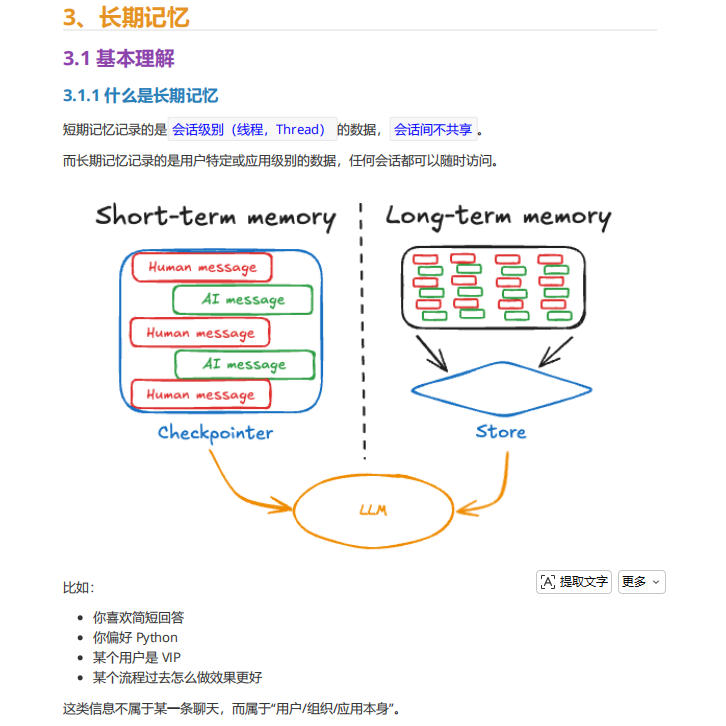
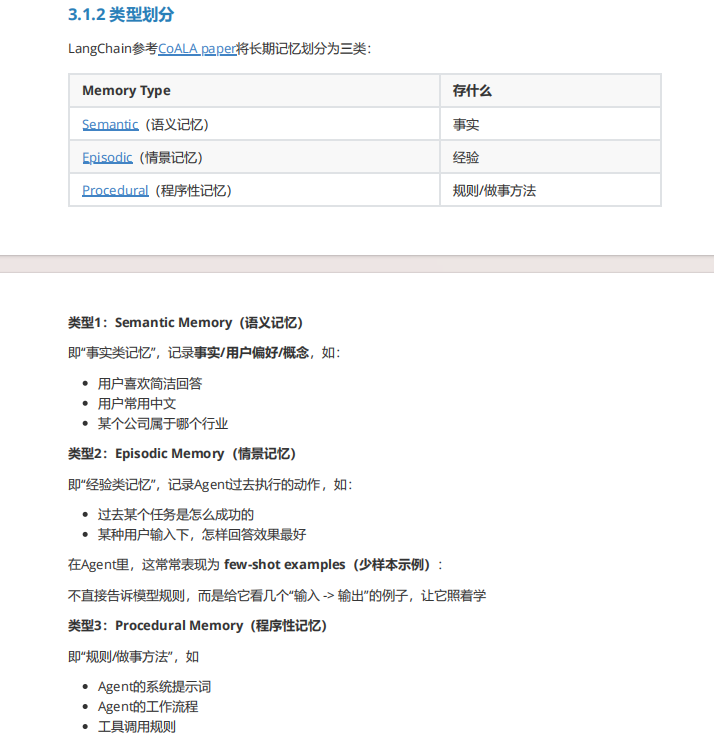
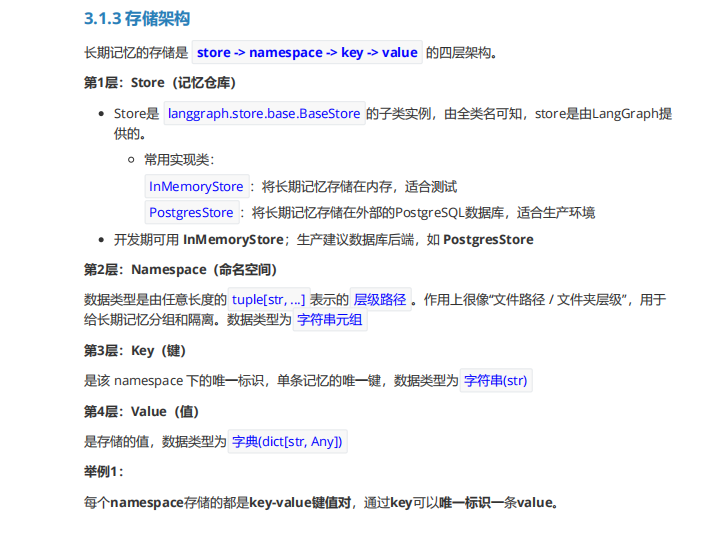

In [ ]:
import os

namespace = ("users", "user_123", "preferences")  # 元组类型
key = "profile"  # 字符串类型
value = {  # 字典类型
    "language": "zh-CN",
    "style": "short_direct",
    "likes": ["python", "rag"]
}
store.put(namespace, key, value)

举例2：
同一个 AI 应用通常会为每个独立会话维护各自的短期状态 State；而长期记忆通常可以共享同一个
Store 实例，再通过 namespace 区分不同用户、组织、业务域或会话相关数据。如下：

AI应用
├─ thread_id = t1 -> state_1
│ ├─ messages = [
│ │ {"role": "user", "content": "我想去北京旅游"},
│ │ {"role": "assistant", "content": "你想玩几天？"}
│ │ ]
│ ├─ current_intent = "travel_planning"
│ └─ collected_slots = {"destination": "北京"}
│
├─ thread_id = t2 -> state_2
│ ├─ messages = [
│ │ {"role": "user", "content": "帮我写周报"}
│ │ ]
│ ├─ current_intent = "write_report"
│ └─ collected_slots = {}
│
├─ thread_id = t3 -> state_3
│ ├─ messages = [
│ │ {"role": "user", "content": "我喜欢简洁风格的UI"}
│ │ ]
│ ├─ current_intent = "ui_design"
│ └─ collected_slots = {"style": "minimal"}
│
└─ shared store
├─ namespace = (user_1, "memories")
│ ├─ key = "profile"
│ │ value = {
│ │ "name": "张三",
│ │ "city": "上海",
│ │ "preferences": ["简洁风格", "中文回复"]
│ │ }
│ ├─ key = "travel_preference"
│ │ value = {
│ │ "favorite_cities": ["北京", "杭州"],
│ │ "budget_level": "medium"
│ │ }
│ └─ key = "writing_style"
│ value = {
│ "tone": "professional",
│ "language": "zh-CN"
│ }
│
├─ namespace = (user_2, "memories")
│ ├─ key = "profile"
│ │ value = {
│ │ "name": "李四",
│ │ "city": "深圳"
│ │ }
│ └─ key = "product_interest"
│ value = {
│ "topics": ["AI Agent", "RAG", "Workflow"]
│ }
│
└─ namespace = (user_1, thread_3, "artifacts")
├─ key = "draft_v1"
│ value = {
│ "type": "html",
│ "content": "<html>...</html>"
│ }
├─ key = "ui_notes"
│ value = {
│ "summary": "用户偏好留白多、低饱和配色"
│ }
└─ key = "final_scheme"
value = {
"palette": ["#F5F1E8", "#1F3A5F", "#D97B2D"],
"font_style": "clean"
}

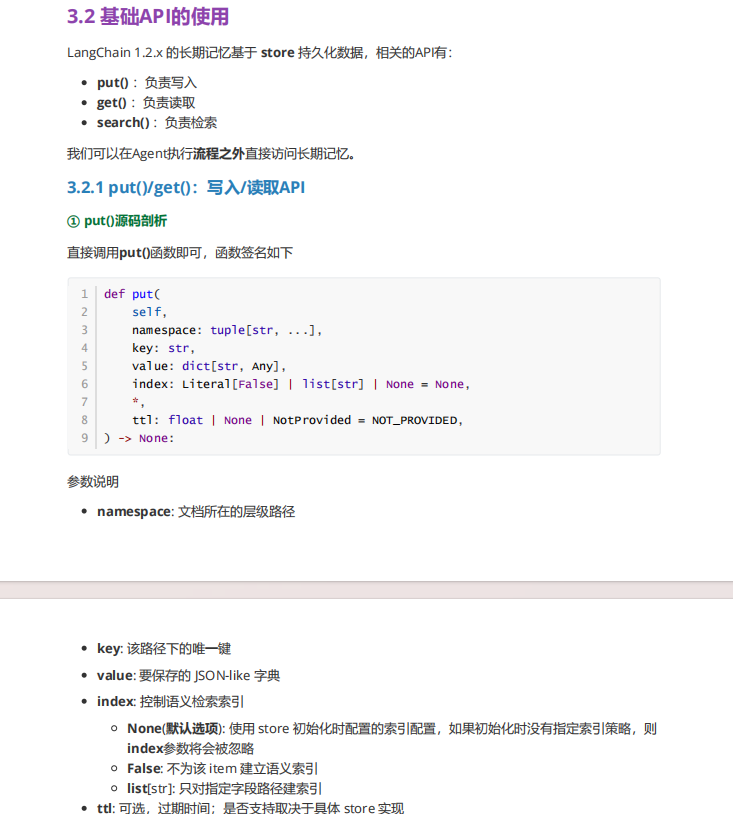
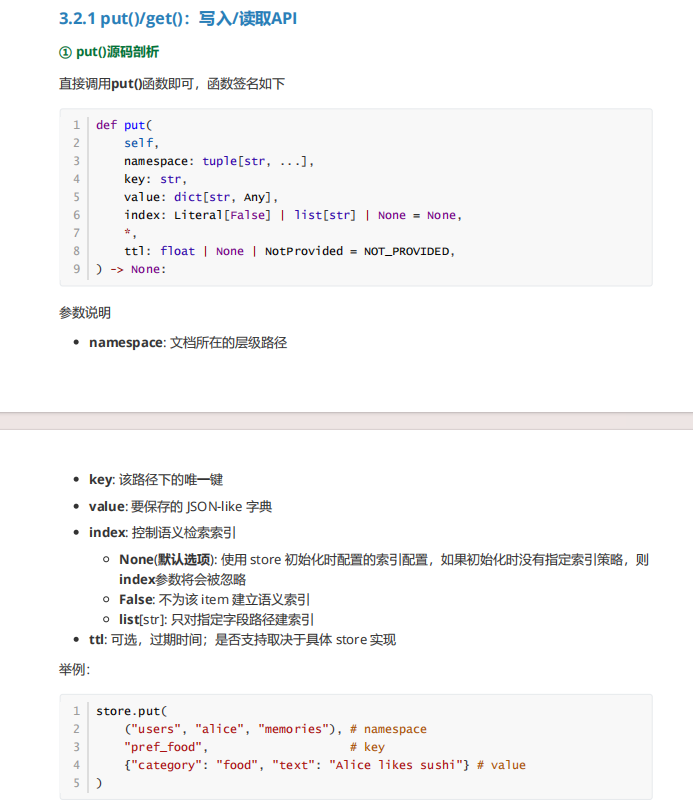
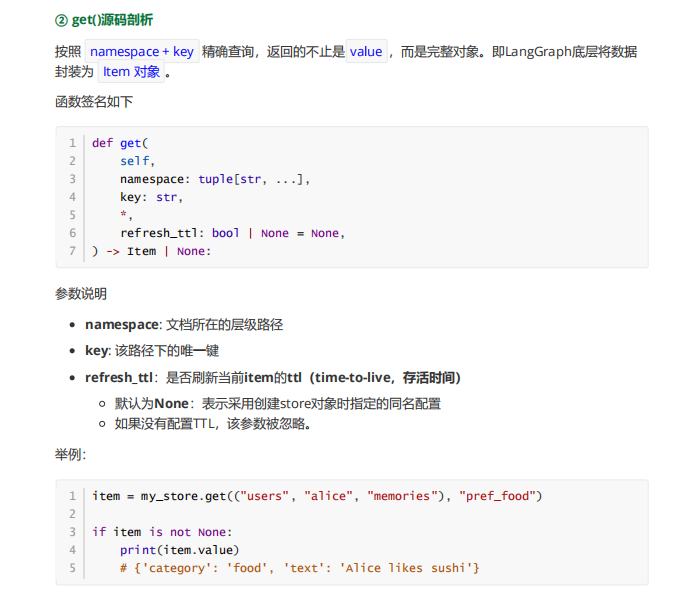

③ 举例1：基于InMemoryStore
举例1：添加

In [1]:
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()
namespace = ("users",)
user_id = 'user-1'
username = "小蓝"
store.put(namespace, user_id, {"name": username})
print(store.get(namespace, user_id))

Item(namespace=['users'], key='user-1', value={'name': '小蓝'}, created_at='2026-07-18T01:46:40.625650+00:00', updated_at='2026-07-18T01:46:40.625652+00:00')


注意到，Item对象新增了 created_at 和 updated_at 字段，分别为数据新增和更改时间。
注意：对于当前版本，InMemoryStore每次put都会创建一个新的Item对象，无论namespace和key是
否相同，所以 created_at 和 updated_at 始终是一致的。

举例2：更新
对同一条数据进行更改后查询。

In [2]:
store.put(namespace, user_id, {"name": '小红'})
print(store.get(namespace, user_id))

Item(namespace=['users'], key='user-1', value={'name': '小红'}, created_at='2026-07-18T01:47:48.431663+00:00', updated_at='2026-07-18T01:47:48.431665+00:00')


④ 举例2：基于PostgresStore
PostgresStore不同于InMemoryStore，更改数据的逻辑是update而非覆盖，因此 created_at 固定为
Item 创建时间，而 updated_at 为更新时间，二者可能不同，符合直觉。
举例1：添加

In [6]:
import os
from langgraph.store.postgres import PostgresStore

namespace = ("users",)
user_id = "user-11"
username = "小蓝"
DB_URL = os.getenv("POSTGRES_URL")
with PostgresStore.from_conn_string(DB_URL) as store:
    store.setup()
    store.put(namespace, user_id, {"name": username})
    print(store.get(namespace, user_id))

Item(namespace=['users'], key='user-11', value={'name': '小蓝'}, created_at='2026-07-18T01:50:26.833575+00:00', updated_at='2026-07-18T01:50:26.833575+00:00')


举例2：更新
更改同一条数据

In [8]:
import os
from langgraph.store.postgres import PostgresStore

DB_URL = os.getenv("POSTGRES_URL")

with PostgresStore.from_conn_string(DB_URL) as store:
    store.setup()
    store.put(namespace, user_id, {"name": "小红"})
    print(store.get(namespace, user_id))

Item(namespace=['users'], key='user-11', value={'name': '小红'}, created_at='2026-07-18T01:50:26.833575+00:00', updated_at='2026-07-18T01:51:47.506616+00:00')


可以看到， created_at 没变，但 updated_at 更改了。

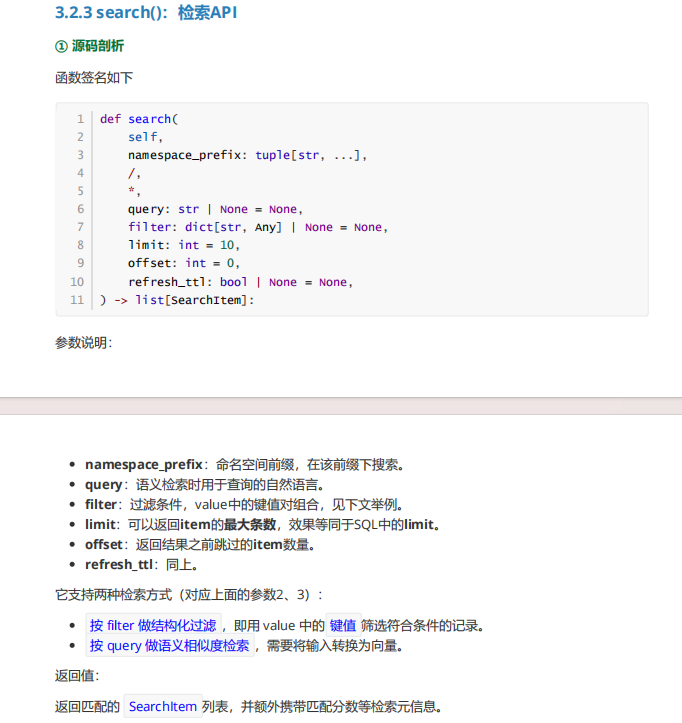

② 举例1：按照namespace前缀搜索
本节全部基于 InMemoryStore 测试。
1、准备store

In [13]:
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()
namespace1 = ("users", "Alice", "memories")
key1 = 'preferences'
value1 = {
    "course": "计算机组成原理",
    "sports": "跑步",
    "food": "紫光园奶皮子酸奶"
}
namespace2 = ("users", "Bob", "memories")
key2 = 'preferences'
value2 = {
    "course": "数字电路与模拟电路",
    "sports": "跑步",
    "food": "奶皮子糖葫芦"
}
namespace3 = ("users", "Black", "memories")
key3 = 'preferences'
value3 = {
    "course": "数字电路与模拟电路",
    "sports": "羽毛球",
    "food": "紫光园奶皮子酸奶"
}
store.put(namespace1, key1, value1)
store.put(namespace2, key2, value2)
store.put(namespace3, key3, value3)



2、按照namespace前缀搜索
代码1

In [11]:
print('=' * 30, '-> (users, ) <-', "=" * 30)
for item in store.search(("users",)):
    print(item)

print('=' * 30, '-> (users, Alice) <-', "=" * 30)
for item in store.search(("users", "Alice")):
    print(item)

============================== -> (users, ) <- ==============================
Item(namespace=['users', 'Alice', 'memories'], key='preferences', value={'course': '计算机组成原理', 'sports': '跑步', 'food': '紫光园奶皮子酸奶'}, created_at='2026-07-18T01:56:21.889742+00:00', updated_at='2026-07-18T01:56:21.889743+00:00', score=None)
Item(namespace=['users', 'Bob', 'memories'], key='preferences', value={'course': '数字电路与模拟电路', 'sports': '跑步', 'food': '奶皮子糖葫芦'}, created_at='2026-07-18T01:56:21.889795+00:00', updated_at='2026-07-18T01:56:21.889796+00:00', score=None)
Item(namespace=['users', 'Black', 'memories'], key='preferences', value={'course': '数字电路与模拟电路', 'sports': '羽毛球', 'food': '紫光园奶皮子酸奶'}, created_at='2026-07-18T01:56:21.889843+00:00', updated_at='2026-07-18T01:56:21.889844+00:00', score=None)
============================== -> (users, Alice) <- ==============================
Item(namespace=['users', 'Alice', 'memories'], key='preferences', value={'course': '计算机组成原理', 'sports': '跑步', 'food': '紫光园奶皮子酸奶

③ 举例2：按照filter过滤
代码1

In [12]:
print("=" * 30, '-> (users, ), filter=food <-", "=" * 30)')
for item in store.search(("users",), filter={"food": "紫光园奶皮子酸奶"}):
    print(item)

============================== -> (users, ), filter=food <-", "=" * 30)
Item(namespace=['users', 'Alice', 'memories'], key='preferences', value={'course': '计算机组成原理', 'sports': '跑步', 'food': '紫光园奶皮子酸奶'}, created_at='2026-07-18T01:56:21.889742+00:00', updated_at='2026-07-18T01:56:21.889743+00:00', score=None)
Item(namespace=['users', 'Black', 'memories'], key='preferences', value={'course': '数字电路与模拟电路', 'sports': '羽毛球', 'food': '紫光园奶皮子酸奶'}, created_at='2026-07-18T01:56:21.889843+00:00', updated_at='2026-07-18T01:56:21.889844+00:00', score=None)


In [14]:
print("=" * 30, '-> (users, ), filter=sports <-", "=" * 30)')
for item in store.search(("users",), filter={"sports": "跑步"}):
    print(item)

============================== -> (users, ), filter=sports <-", "=" * 30)
Item(namespace=['users', 'Alice', 'memories'], key='preferences', value={'course': '计算机组成原理', 'sports': '跑步', 'food': '紫光园奶皮子酸奶'}, created_at='2026-07-18T01:57:37.984091+00:00', updated_at='2026-07-18T01:57:37.984093+00:00', score=None)
Item(namespace=['users', 'Bob', 'memories'], key='preferences', value={'course': '数字电路与模拟电路', 'sports': '跑步', 'food': '奶皮子糖葫芦'}, created_at='2026-07-18T01:57:37.984138+00:00', updated_at='2026-07-18T01:57:37.984139+00:00', score=None)


In [15]:
print("=" * 30, '-> (users, ), filter=course <-", "=" * 30)')
for item in store.search(("users",), filter={"course": "数字电路与模拟电路"}):
    print(item)

============================== -> (users, ), filter=course <-", "=" * 30)
Item(namespace=['users', 'Bob', 'memories'], key='preferences', value={'course': '数字电路与模拟电路', 'sports': '跑步', 'food': '奶皮子糖葫芦'}, created_at='2026-07-18T01:57:37.984138+00:00', updated_at='2026-07-18T01:57:37.984139+00:00', score=None)
Item(namespace=['users', 'Black', 'memories'], key='preferences', value={'course': '数字电路与模拟电路', 'sports': '羽毛球', 'food': '紫光园奶皮子酸奶'}, created_at='2026-07-18T01:57:37.984177+00:00', updated_at='2026-07-18T01:57:37.984178+00:00', score=None)


④ 举例3：按照语义搜索
举例1：自定义嵌入函数
自定义嵌入函数，目的是查看嵌入向量

In [16]:
from langgraph.store.memory import InMemoryStore


# 自定义嵌入函数
def embed(text: list[str]) -> list[list[float]]:
    return [[1.0] * 6 for _ in range(len(text))]


index_config = {
    "embed": embed,
    "dims": 6,
    "fields": ["$", "course"]
}

store = InMemoryStore(
    index=index_config
)

namespace1 = ("users", "Alice", "memories")
key1 = 'preferences'
value1 = {
    "course": "计算机组成原理",
    "sports": "跑步",
    "food": "紫光园奶皮子酸奶"
}
namespace2 = ("users", "Bob", "memories")
key2 = 'preferences'
value2 = {
    "course": "数字电路与模拟电路",
    "sports": "跑步",
    "food": "奶皮子糖葫芦"
}
namespace3 = ("users", "Black", "memories")
key3 = 'preferences'
value3 = {
    "course": "数字电路与模拟电路",
    "sports": "羽毛球",
    "food": "紫光园奶皮子酸奶"
}
store.put(namespace1, key1, value1)
store.put(namespace2, key2, value2)
store.put(namespace3, key3, value3)

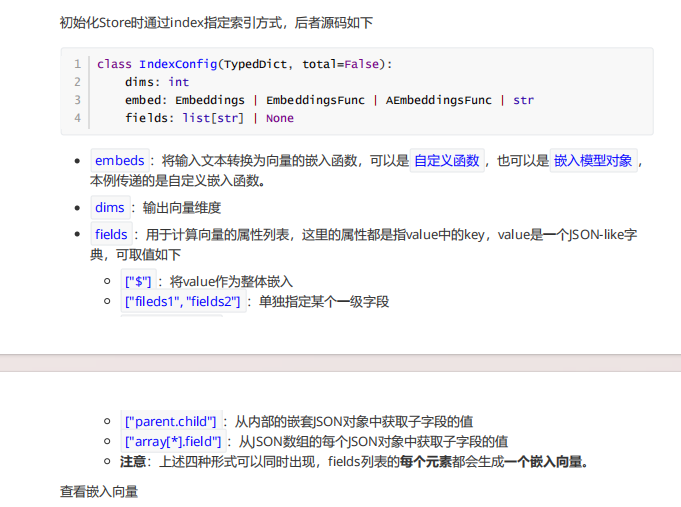

In [17]:
from pprint import pprint

pprint(store._vectors)

defaultdict(<function InMemoryStore.__init__.<locals>.<lambda> at 0x000001A7071EC860>,
            {('users', 'Alice', 'memories'): defaultdict(<class 'dict'>,
                                                         {'preferences': {'$': [1.0,
                                                                                1.0,
                                                                                1.0,
                                                                                1.0,
                                                                                1.0,
                                                                                1.0],
                                                                          'course': [1.0,
                                                                                     1.0,
                                                                                     1.0,
                                                           

还可以通过指定namespace、key、index_config的fields中指定的字段名查看特定向量。

In [18]:
from pprint import pprint

pprint(store._vectors[('users', 'Alice', 'memories')]['preferences']['$'])

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


举例2：使用嵌入模型
本例要通过CloseAI平台调用OpenAI的嵌入模型 openai:text-embedding-3-large
其嵌入维度为3072，所以此处的 dims 应设置为3072

In [ ]:
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
from langchain.embeddings import init_embeddings
import os

load_dotenv(override=True)
embedding_model = init_embeddings(
    model="openai:text-embedding-3-large",
    api_key=os.getenv("CLOSEAI_API_KEY"), base_url=os.getenv("CLOSEAI_BASE_URL"),
)

index_config = {
    "embed": embedding_model,
    "dims": 3072,
    "fields": ["$"]
}

store = InMemoryStore(
    index=index_config
)
namespace1 = ("users", "Alice", "memories")
key1 = 'preferences'
value1 = {
    "course": "计算机组成原理",
    "sports": "跑步",
    "food": "紫光园奶皮子酸奶"
}
namespace2 = ("users", "Bob", "memories")
key2 = 'preferences'
value2 = {
    "course": "数字电路与模拟电路",
    "sports": "跑步",
    "food": "奶皮子糖葫芦"
}
namespace3 = ("users", "Black", "memories")
key3 = 'preferences'
value3 = {
    "course": "数字电路与模拟电路",
    "sports": "羽毛球",
    "food": "紫光园奶皮子酸奶"
}
store.put(namespace1, key1, value1)
store.put(namespace2, key2, value2)
store.put(namespace3, key3, value3)

注意：如果只是指定了 query ，返回的是所有 namespace 前缀满足要求的 item 。底层会按照向量相
似度计算查询和候选的 score ，输出结果按照score 降序排列 。可以结合 limit 或 filter 限制数据条
数。这里不再演示。